In [33]:
RUTA_RADIOMICAS = 'csv/radiomicas_combinadas_normalizado.csv'
RUTA_CLINICAS = 'csv/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'
MODELO_A_USAR = 'rsf_mixed.pkl'


In [34]:
import sys
from pathlib import Path
try:
    import pandas as pd
except ImportError:
    print("Error: 'pandas' is not installed on this machine.")
    print("Please install it by running: pip install pandas")
    sys.exit(1)
try:
    import sklearn
except ImportError:
    print("Error: 'scikit-learn' is not installed on this machine.")
    print("Please install it by running: pip install scikit-learn")
    sys.exit(1)

In [35]:
df_radiomics = pd.read_csv(RUTA_RADIOMICAS)
df_radiomics["Patient"] = df_radiomics["Patient"].str.replace('"','',regex=False)
df_clinic = pd.read_csv(RUTA_CLINICAS)

df_clinic = df_clinic.dropna(subset=["Overall.Stage"])
df_clinic = df_clinic[df_clinic["PatientID"].isin(df_radiomics["Patient"])]  
df_radiomics = df_radiomics[df_radiomics["Patient"].isin(df_clinic["PatientID"])]

if MODELO_A_USAR == 'rsf_top_radiomics.pkl':
    features = ["wavelet-LLH_ngtdm_Coarseness","original_gldm_DependenceNonUniformity", "wavelet-HHL_ngtdm_Coarseness", "wavelet-HHL_glrlm_RunLengthNonUniformity"]
    X_test = df_radiomics[features].values

elif MODELO_A_USAR == 'rsf_clinics.pkl':
    features = df_clinic.columns[1:8]
    X = df_clinic[features]
    categorical_features = ['Overall.Stage', 'Histology', 'gender']
    preprocessor = sklearn.compose.ColumnTransformer(
    transformers=[
        ('cat', sklearn.preprocessing.OneHotEncoder(sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)
    X_test = preprocessor.fit_transform(X)
elif MODELO_A_USAR == 'rsf_mixed.pkl':
    
    features_clinic = df_clinic.columns[1:8]
    features_radiomics = ["wavelet-LLH_ngtdm_Coarseness","original_gldm_DependenceNonUniformity", "wavelet-HHL_ngtdm_Coarseness", "wavelet-HHL_glrlm_RunLengthNonUniformity"]

    X_clinic = df_clinic[features_clinic].reset_index(drop=True)
    X_radiomics = df_radiomics[features_radiomics].reset_index(drop=True)

    X = pd.concat([X_clinic, X_radiomics], axis=1)

    categorical_features = ['Overall.Stage', 'Histology', 'gender']
    preprocessor = sklearn.compose.ColumnTransformer(
    transformers=[
        ('cat', sklearn.preprocessing.OneHotEncoder(sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)
    X_test = preprocessor.fit_transform(X)


Success: Loaded rsf_mixed.pkl successfully!


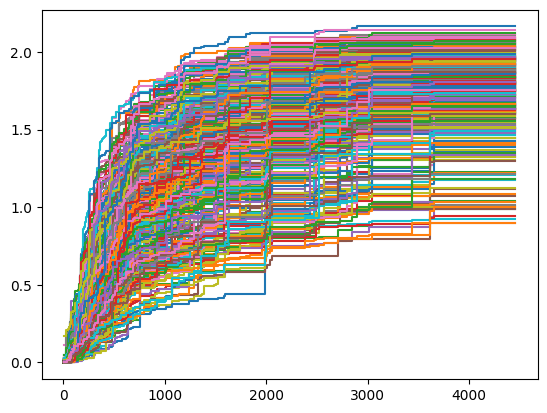

In [36]:


try:
    import joblib
except ImportError:
    print("Error: 'joblib' is not installed on this machine.")
    print("Please install it by running: pip install joblib scikit-learn")
    sys.exit(1)



try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Error: 'matplotlib' is not installed on this machine.")
    print("Please install it by running: pip install matplotlib")
    sys.exit(1)


def load_model_safely(folder_name, model_name):
    """
    Loads a .pkl model from a folder relative to where this script is running.
    Works on Windows, Mac, and Linux.
    """

    current_dir = Path.cwd()
    
    model_path = current_dir / folder_name / model_name
    
    if not model_path.exists():
        print(f"Error: Could not find the model file at: {model_path.resolve()}")
        print("Please ensure the folder and file names are correct.")
        return None

    try:
        model = joblib.load(model_path)
        print(f"Success: Loaded {model_name} successfully!")
        return model
    except Exception as e:
        print(f"Error loading the model: {e}")
        print("Tip: Ensure the scikit-learn version matches the version used to train the model.")
        return None

if __name__ == "__main__":
    MY_FOLDER = "models" 
    MY_MODEL = MODELO_A_USAR
    
    model = load_model_safely(MY_FOLDER, MY_MODEL)
    
    if model:
        chf_functions = model.predict_cumulative_hazard_function(X_test)
        for fn in chf_functions:
            plt.step(fn.x, fn(fn.x), where="post")
        plt.show()
